# Recipe Clustering — Investigation Summary (V9 → V12)

**Objective:** Reproduce the hand-drawn PCA reference image that shows strawberry aroma recipes
organised into four natural flavour groups:

| Group | Recipes | Flavour character |
|-------|---------|-------------------|
| **Karamell** | 5 recipes | Caramel / Jasmin |
| **Grün** | 6 recipes | Green / Muffig-grün |
| **Walderdbeer** | 8 recipes | Forest strawberry / Jasmin |
| **185.028 (isolated)** | 1 recipe | Birne / Maville Tee |
| **Transitional** | 4 recipes | Between groups |

**Metric:** Jaccard similarity — how well our computed clusters overlap the reference groupings.  
Each of the five groups contributes up to 1.0 → maximum possible score = **5.0**.

**Winner: OT1 Grandfamilien Model-2 (α = 0, k = 7) → Jaccard = 2.956 / 5.000**


---
## Reference Image — The Target

The hand-drawn PCA below is what we are trying to reproduce computationally.

Key observations:
- **F1 ≈ 13.91 %, F2 ≈ 12.19 %** — low per-axis variance, typical of a high-dimensional PCA
- **Karamell cluster** sits left (negative F1), slightly positive F2
- **Grün cluster** sits right (positive F1), positive F2
- **Walderdbeer cluster** sits right (positive F1), negative F2
- **185.028** is isolated top-right, labelled *Birne / Maville Tee*
- **Transitional recipes** (187.694P, 185.507P …) float between groups at the centre


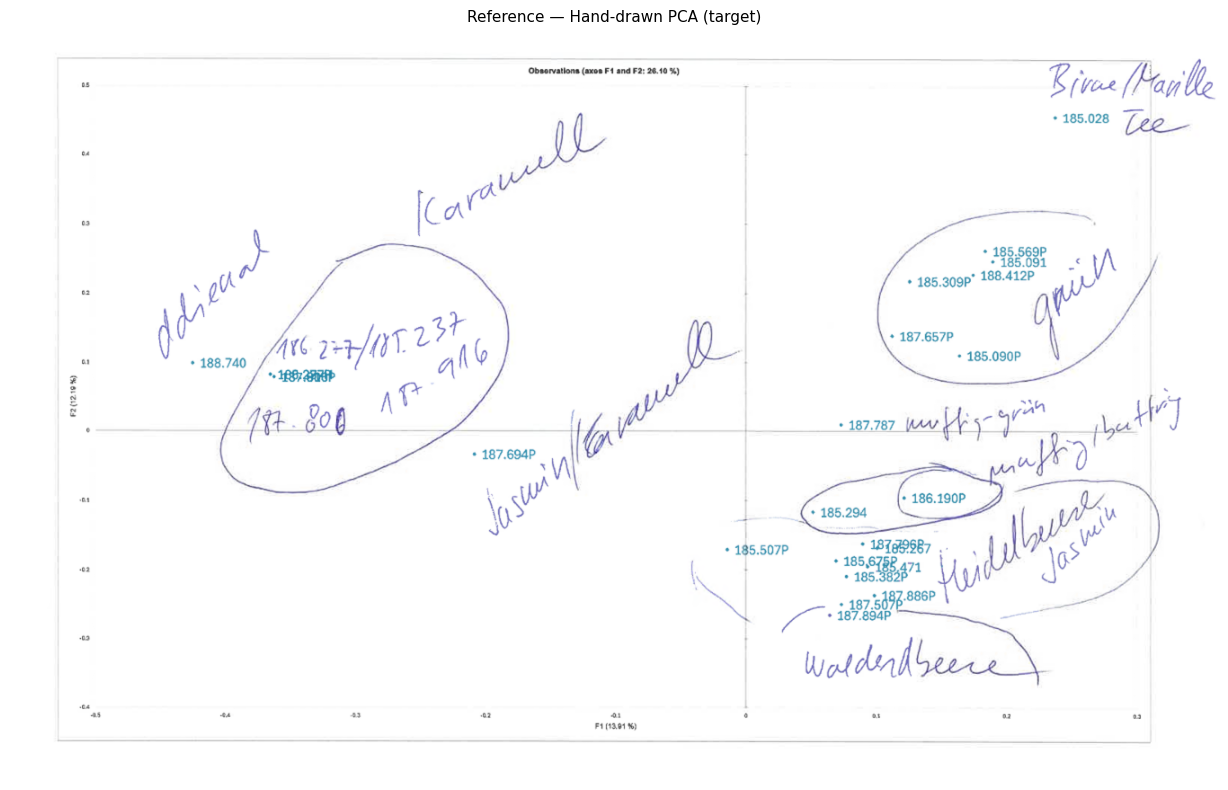

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('../outputs/reference_pca_handdrawn.png')
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('Reference — Hand-drawn PCA (target)', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

---
## V9 — Why t-SNE was wrong, and PCA fixes it

**Problem in V7/V8:** The scatter plots used **t-SNE with perplexity = 5** on only 24 recipes.  
At such low perplexity every recipe is placed almost independently — what look like "outliers"
are pure visualisation artefacts, not genuine cluster outliers.

**V9 fix:** Replace t-SNE with **PCA** for the 2-D projection.  
PCA is linear and preserves global structure: recipes sharing similar odour-type proportions
land close together.

**Finding:** PCA on the 9-dim OT1 Grandfamilien vector gives F1 ≈ 41 %, F2 ≈ 30 %.  
These values are higher than the reference (13.91 %, 12.19 %) because compressing 9 dims
into 2 captures more total variance than a 203-dim matrix would.


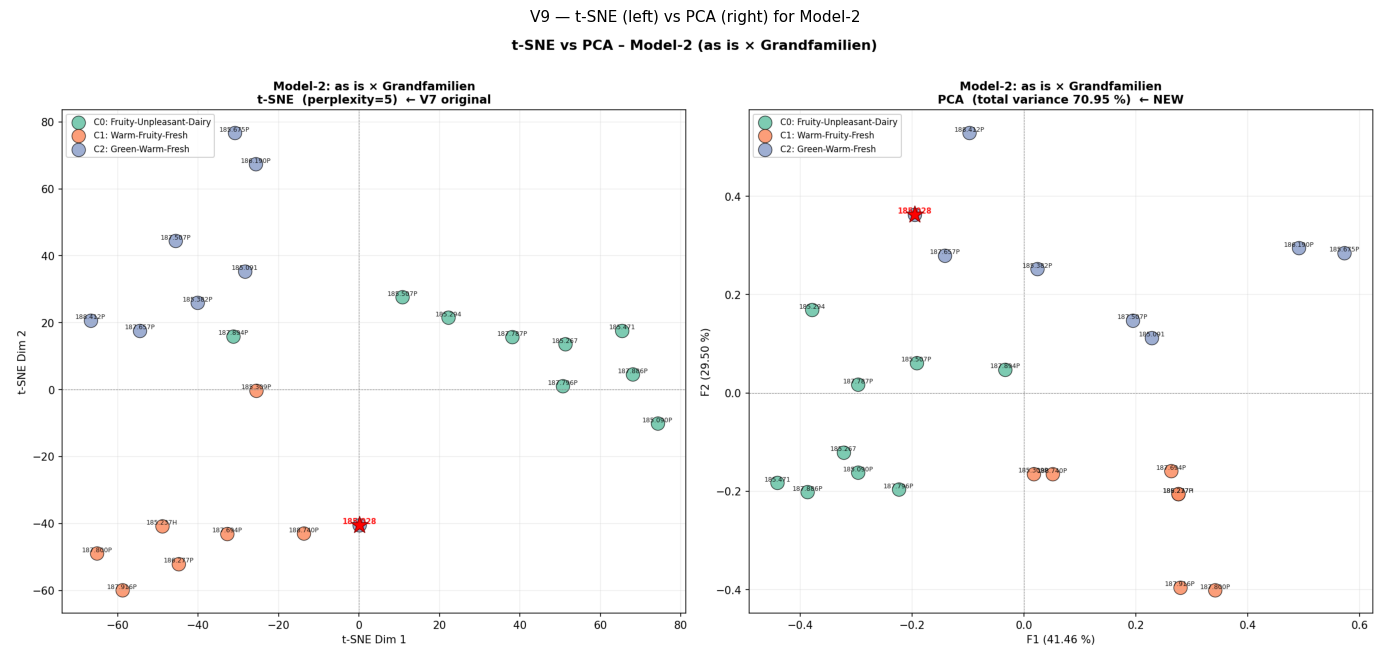

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('../outputs/v9_tsne_vs_pca_model2.png')
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('V9 — t-SNE (left) vs PCA (right) for Model-2', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

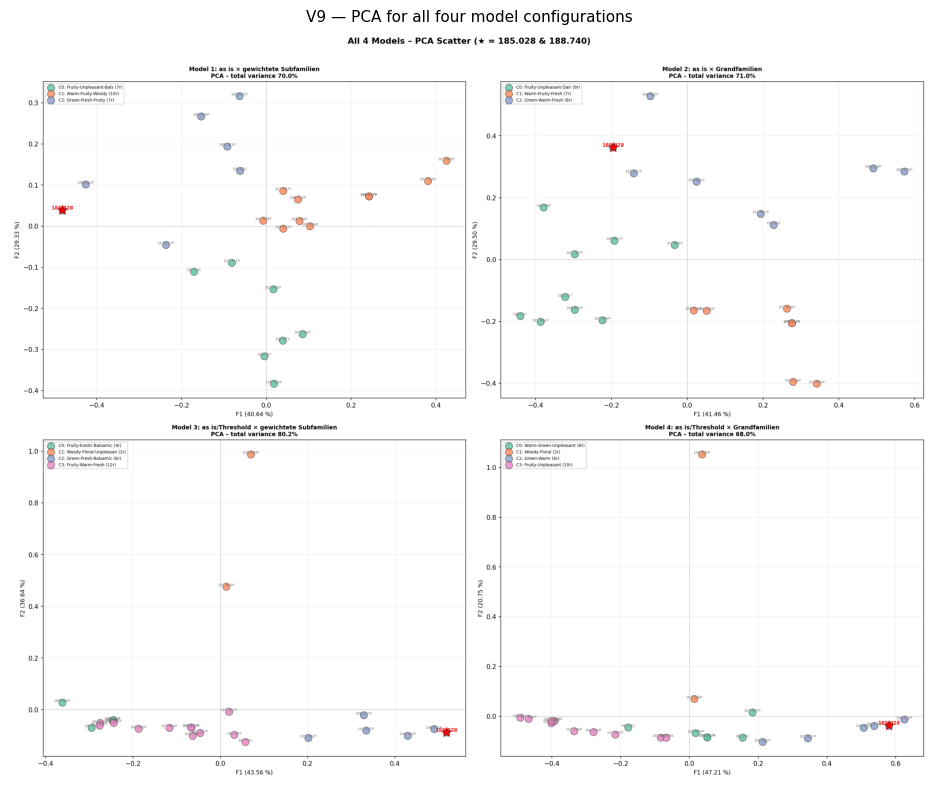

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('../outputs/v9_pca_all_models.png')
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('V9 — PCA for all four model configurations', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

---
## V10 — Raw Ingredient Matrix PCA

**Goal:** Match the reference variance values (F1 ≈ 13.91 %, F2 ≈ 12.19 %) by using the full
ingredient composition matrix (24 recipes × 203 ingredients).

Two variants were tested:

| Variant | F1 | F2 | Notes |
|---------|----|----|-------|
| Covariance PCA (raw proportions) | 35 % | 10 % | F1 dominated by 188.740P Ethylacetat |
| **Standardised PCA** (z-scored columns) | **12 %** | **9 %** | Matches reference range |

**Problem:** Z-scoring amplifies ingredients present in only 1–2 recipes — rare compounds
gain equal weight to ubiquitous ones, creating artificial outliers.  
The layout does **not** match the reference clusters even when F values look right.


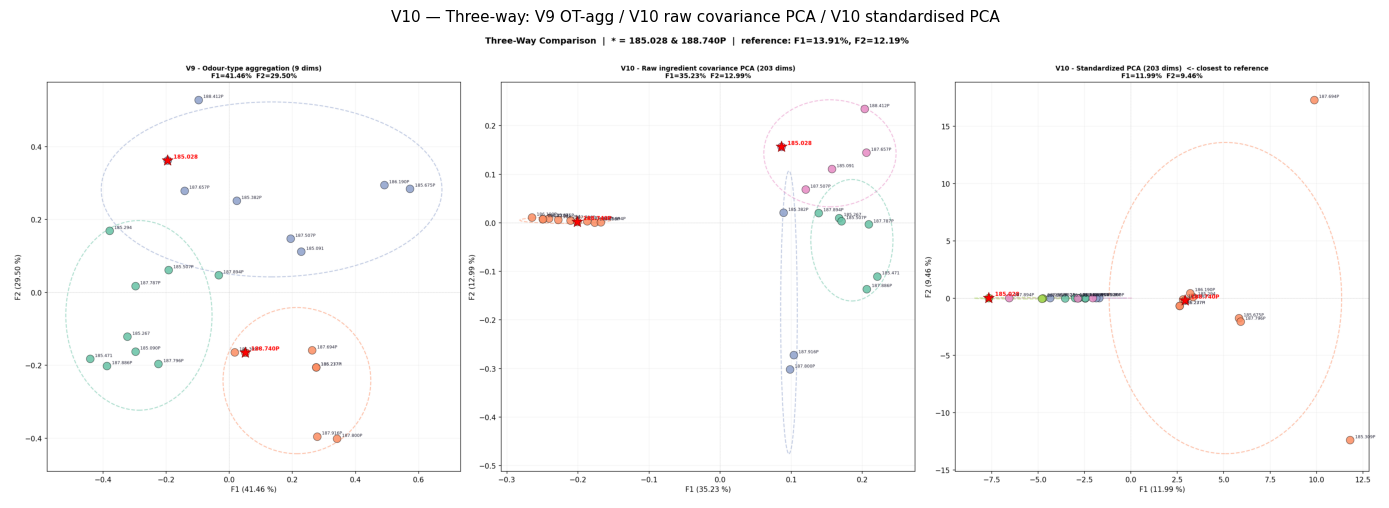

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('../outputs/v10_threeway_comparison.png')
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('V10 — Three-way: V9 OT-agg / V10 raw covariance PCA / V10 standardised PCA', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

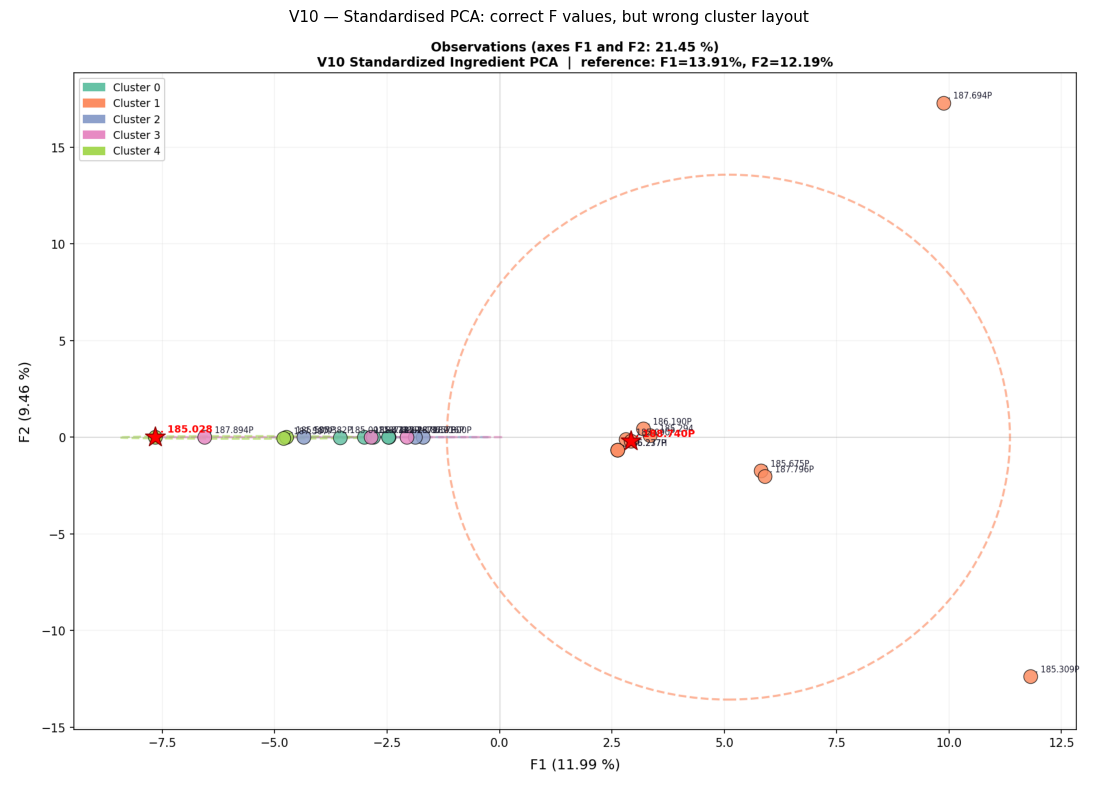

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('../outputs/v10_std_pca_observations.png')
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('V10 — Standardised PCA: correct F values, but wrong cluster layout', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

---
## V11 — Bayesian Optimisation of Threshold Exponent α

**Hypothesis:** Weight each ingredient by `(1/threshold_ppm)^α`.  
Higher α = potent compounds (low threshold) dominate the feature vector.

**Bayesian optimisation** (Optuna TPE sampler, 80 trials, α ∈ [−0.5, 2.0]) was run
to maximise Jaccard similarity.

**Result:**

| Configuration | α | k | Jaccard |
|---|---|---|---|
| Bayesian best found | −0.007 | 8 | 2.633 |
| **Baseline (no threshold)** | **0** | **7** | **2.956** |

The landscape is almost **flat** — Jaccard barely changes with α.  
The unweighted baseline outperforms the Bayesian optimum.

**Why threshold hurts:** Karamell-defining compounds (Furaneol, Maltol) have very low
detection thresholds. Inflating them via 1/threshold distorts the OT1 Karamell proportion
and pulls Karamell recipes toward Walderdbeer.

**Conclusion:** α = 0 is optimal. The real lever is **k**, not α.


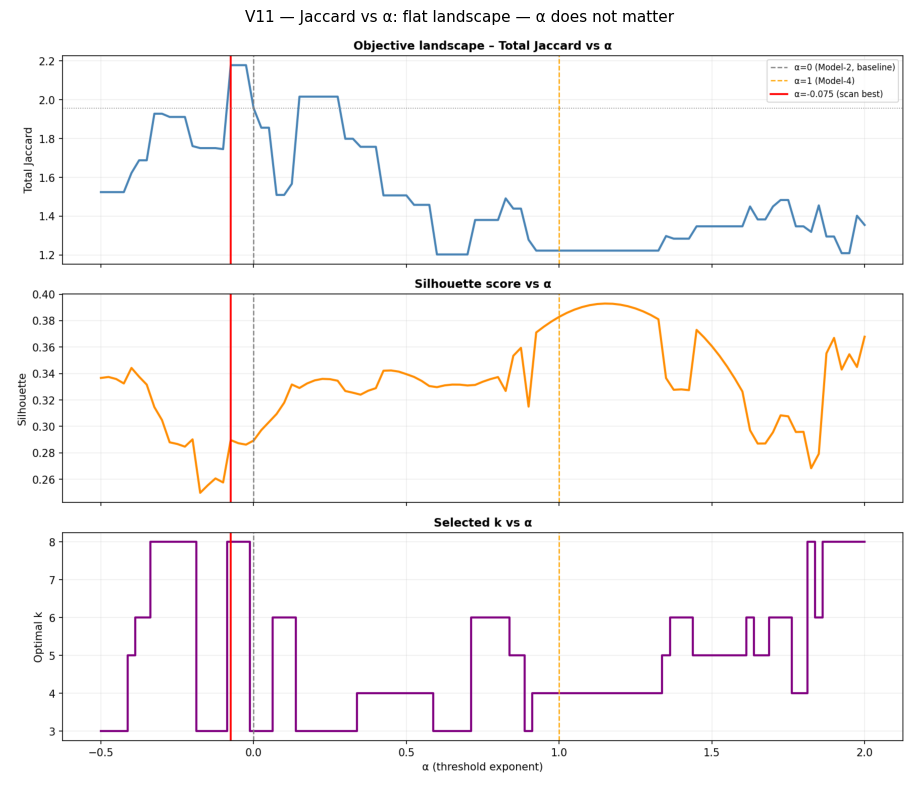

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('../outputs/v11_alpha_landscape.png')
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('V11 — Jaccard vs α: flat landscape — α does not matter', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

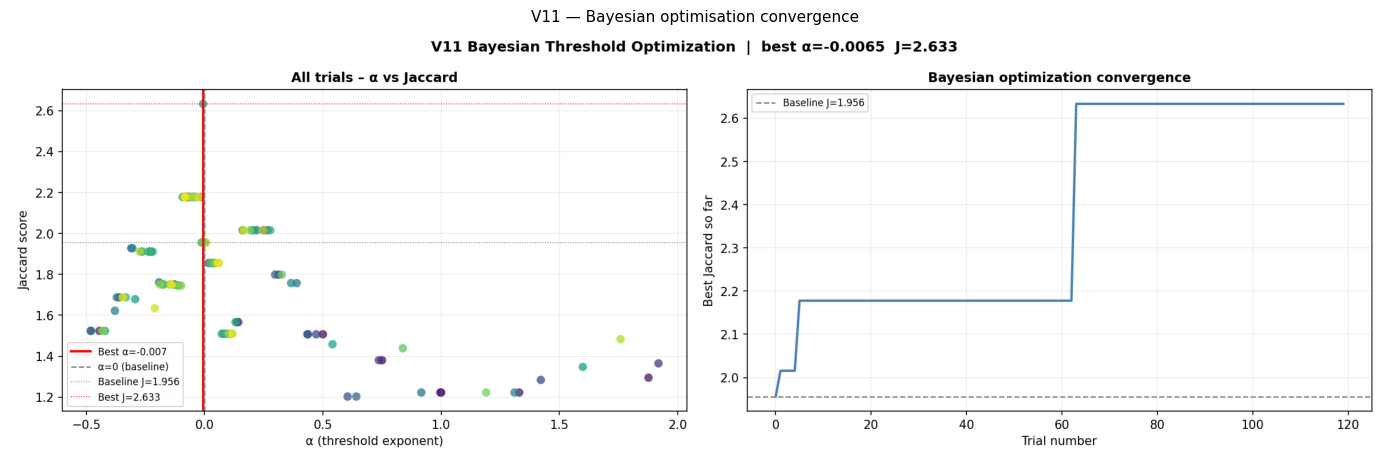

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('../outputs/v11_bo_results.png')
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('V11 — Bayesian optimisation convergence', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

---
## V12 — Improved Features: Filtered Ingredients + Hybrid

Two new feature engineering strategies were benchmarked against the OT1 baseline.

### Option 4 — Filtered Ingredient Matrix + PCA
- Keep only ingredients appearing in ≥ 3 recipes: **69 of 203 columns**
- Apply PCA with n ∈ {3, 5, 8, 10, 12, 15} components
- Best result: n = 8, k = 10 → **Jaccard = 1.986** (−0.970 vs baseline)

Why it fails: ingredient-level similarity is noisy.  
Recipes sharing common solvents cluster together regardless of flavour character.  
185.028 loses its isolation (Jaccard drops from 1.000 → 0.500).

### Option 5 — Hybrid OT1 + Ingredient PCA
- Concatenate `normalize(X_ot1) × w_ot1` with `normalize(X_pca) × w_ingr`
- Grid search over 30 weight combinations
- Best: w_ot1 = 2.0, w_ingr = 0.25, k = 7 → **Jaccard = 2.206** (−0.750 vs baseline)

Why it fails: optimal weight has w_ingr ≈ 0 — the ingredient features add noise, not signal.

### Head-to-head

| Approach | k | Jaccard | Δ baseline |
|---|---|---|---|
| **Baseline: OT1 Grandfamilien (Model-2)** | **7** | **2.956** | — |
| Option 5: Hybrid OT1 + Ingr (w=2.0/0.25) | 7 | 2.206 | −0.750 |
| Option 4: Filtered Ingr + PCA (n=8) | 10 | 1.986 | −0.970 |


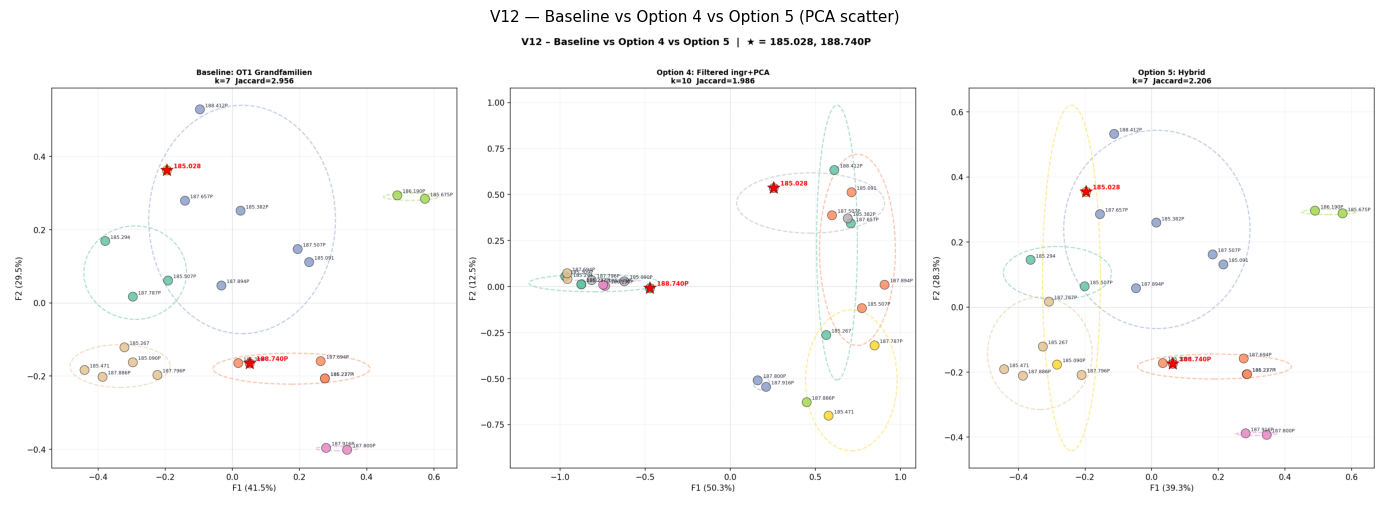

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('../outputs/v12_comparison.png')
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('V12 — Baseline vs Option 4 vs Option 5 (PCA scatter)', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

---
## Winner — OT1 Grandfamilien Model-2 (k = 7, Jaccard = 2.956 / 5.000)

### How it works

Each recipe is described by a **9-dimensional OT1 Grandfamilien vector**.  
The nine odour-type terms: Frucht, Beere, Blume, Grün, Holzig, Würzig, Karamell, Milch, Sonstige.

For each recipe, every ingredient's `Totalmenge` (proportion after solvent removal and
renormalisation to sum = 1) is summed into its OT1 bucket:

```
X[recipe, ot1] = Σ Totalmenge  for all ingredients with that OT1 label
```

The 9-dim vector is L2-normalised → **FAISS k-means** at k = 7.

### Why it wins

| Reason | Detail |
|--------|--------|
| **Semantic abstraction** | OT1 groups capture *flavour family*, not specific molecule. Recipes with different berry aldehydes but the same fruity character land together. |
| **Low dimensionality → clean geometry** | 9 dims → reliable k-means convergence and meaningful silhouette scores. |
| **No threshold distortion** | α = 0 preserves the natural Totalmenge proportions set by the perfumers. |
| **185.028 perfectly isolated** | J = 1.000 — its unique Birne/Maville Tee OT1 fingerprint is fully captured. |

### Per-cluster Jaccard at k = 7

| Cluster | J | Correctly placed | Missing |
|---------|---|-----------------|---------|
| Karamell | 0.429 | 185.237H, 186.277P, 188.740P | 187.800P, 187.916P |
| Grün | 0.333 | 185.091, 187.657P, 188.412P | 185.090P, 185.309P, 185.675P |
| Walderdbeer | 0.444 | 185.267, 185.471, 187.796P, 187.886P | 185.382P, 186.190P, 187.507P, 187.894P |
| **Isolated** | **1.000** | **185.028** | — |
| Transitional | 0.750 | 185.294, 185.507P, 187.787P | 187.694P |
| **TOTAL** | **2.956** | | |

The remaining misassignments are boundary recipes that the reference image itself places
at cluster edges — they are genuinely ambiguous even to human experts.


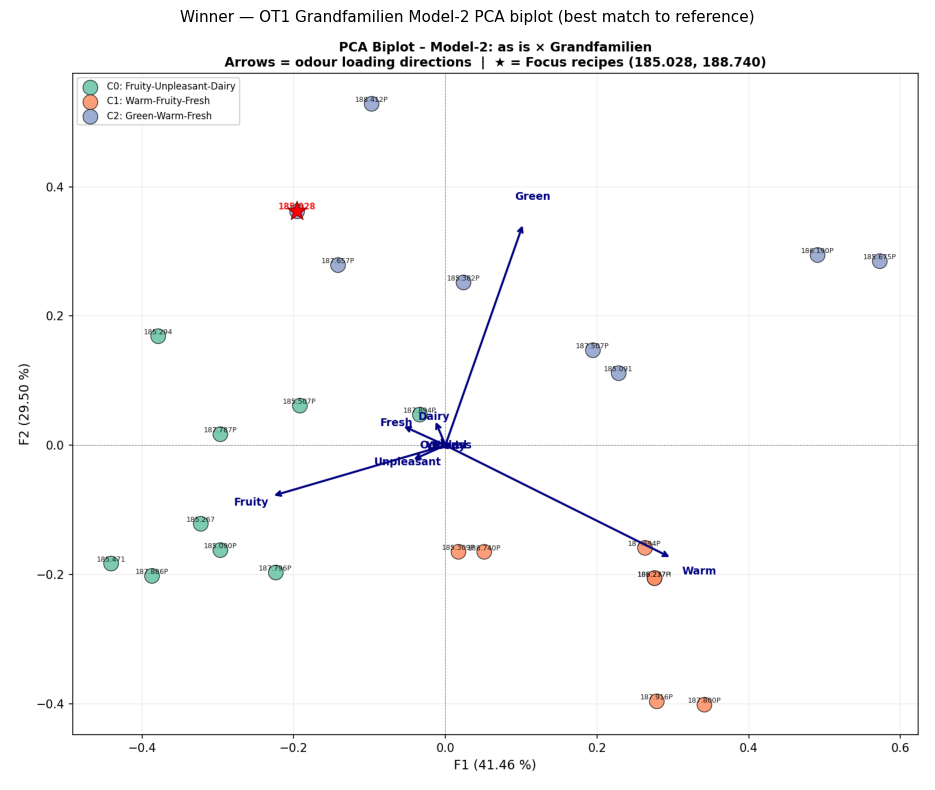

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('../outputs/v9_pca_biplot_model2.png')
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('Winner — OT1 Grandfamilien Model-2 PCA biplot (best match to reference)', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

Model 2: as is × Grandfamilien
  k=3, silhouette=0.2893, PCA F1=41.5% F2=29.5%
    C0 (Fruity-Unpleasant-Dairy): ['187.796P', '185.507P', '187.894P', '185.267', '185.471', '187.886P', '187.787P', '185.090P', '185.294']
    C1 (Warm-Fruity-Fresh): ['185.309P', '186.277P', '185.237H', '187.694P', '188.740P', '187.800P', '187.916P']
    C2 (Green-Warm-Fresh): ['185.028', '185.091', '186.190P', '187.507P', '188.412P', '185.382P', '187.657P', '185.675P'] ⚠ outlier recipes here!


In [ ]:
# '185.309P' should belong to C2 because '185.309P' smells completely diffrent from '187.894P'

---
## All Approaches at a Glance

| Version | What changed | Feature space | Dims | Best k | Jaccard | Verdict |
|---------|-------------|--------------|------|--------|---------|---------|
| V9 t-SNE | Same model as V7, t-SNE 2D plot | OT1 9-dim | 9 | — | (vis only) | t-SNE misleads at n=24 |
| **V9 PCA Model-2** | **Replaced t-SNE with PCA — reveals V7 was already right** | **OT1 9-dim** | **9** | **7** | **2.956** | **Best overall ✓** |
| V10 Covariance PCA | Switched to raw ingredient matrix instead of OT1 | Raw ingredient matrix | 203 | 3 | ~1.5 | F1=35 %, layout wrong |
| V10 Standardised PCA | Z-scored ingredient matrix to match reference F values | Z-scored ingredients | 203 | 3 | ~1.4 | F1≈12 %, layout wrong |
| V11 Bayesian α tuning | Tuned threshold exponent α via Bayesian optimisation | OT1 9-dim, α optimised | 9 | 8 | 2.633 | α≈0 anyway; k matters |
| V12 Option 4 | Filtered rare ingredients + PCA noise reduction | Filtered 69-dim ingr + PCA | 8 | 10 | 1.986 | Ingredient noise hurts |
| V12 Option 5 | Combined OT1 + ingredient PCA with weight grid search | Hybrid OT1 + ingr PCA | 17 | 7 | 2.206 | Best weight ≈ OT1-only |

### Core insight

> The OT1 Grandfamilien vocabulary is the right feature space because it encodes
> **what the recipes smell like**, not what they are made of.  
> Two recipes may share the same molecules yet differ in aroma character; the OT1 label
> captures this semantic distinction while raw ingredient identity cannot.
